Returns : (10330, 117)
Regimes : (10160, 10)
Range   : 1989-07-31 -> 2026-03-13

Data split summary:
Split               Start           End    Days   Years  Key events
--------------------------------------------------------------------------------
  TRAIN        1995-01-01    2014-12-31   5,741    22.8  Asian crisis, dot-com, GFC, EU debt
  VALIDATION   2015-01-01    2019-12-31   1,330     5.3  China shock, 2018 selloff, trade war
  TEST         2020-01-01    2026-03-13   1,647     6.5  Covid, Ukraine, inflation, AI

Branch scores loaded: (10331, 6)

Classifier applied to 10,331 days

REGIME DISTRIBUTION — TRAIN vs VALIDATION vs TEST

  Regime                  TRAIN    VALIDATION          TEST
-------------------------------------------------------
  CRISIS                   8.3%         17.4%         11.1%
  RATE CYCLE              23.4%         27.7%         19.7%
  RISK-OFF                 6.2%          4.3%          6.8%
  RISK-ON                 19.7%          4.5%         17.3%

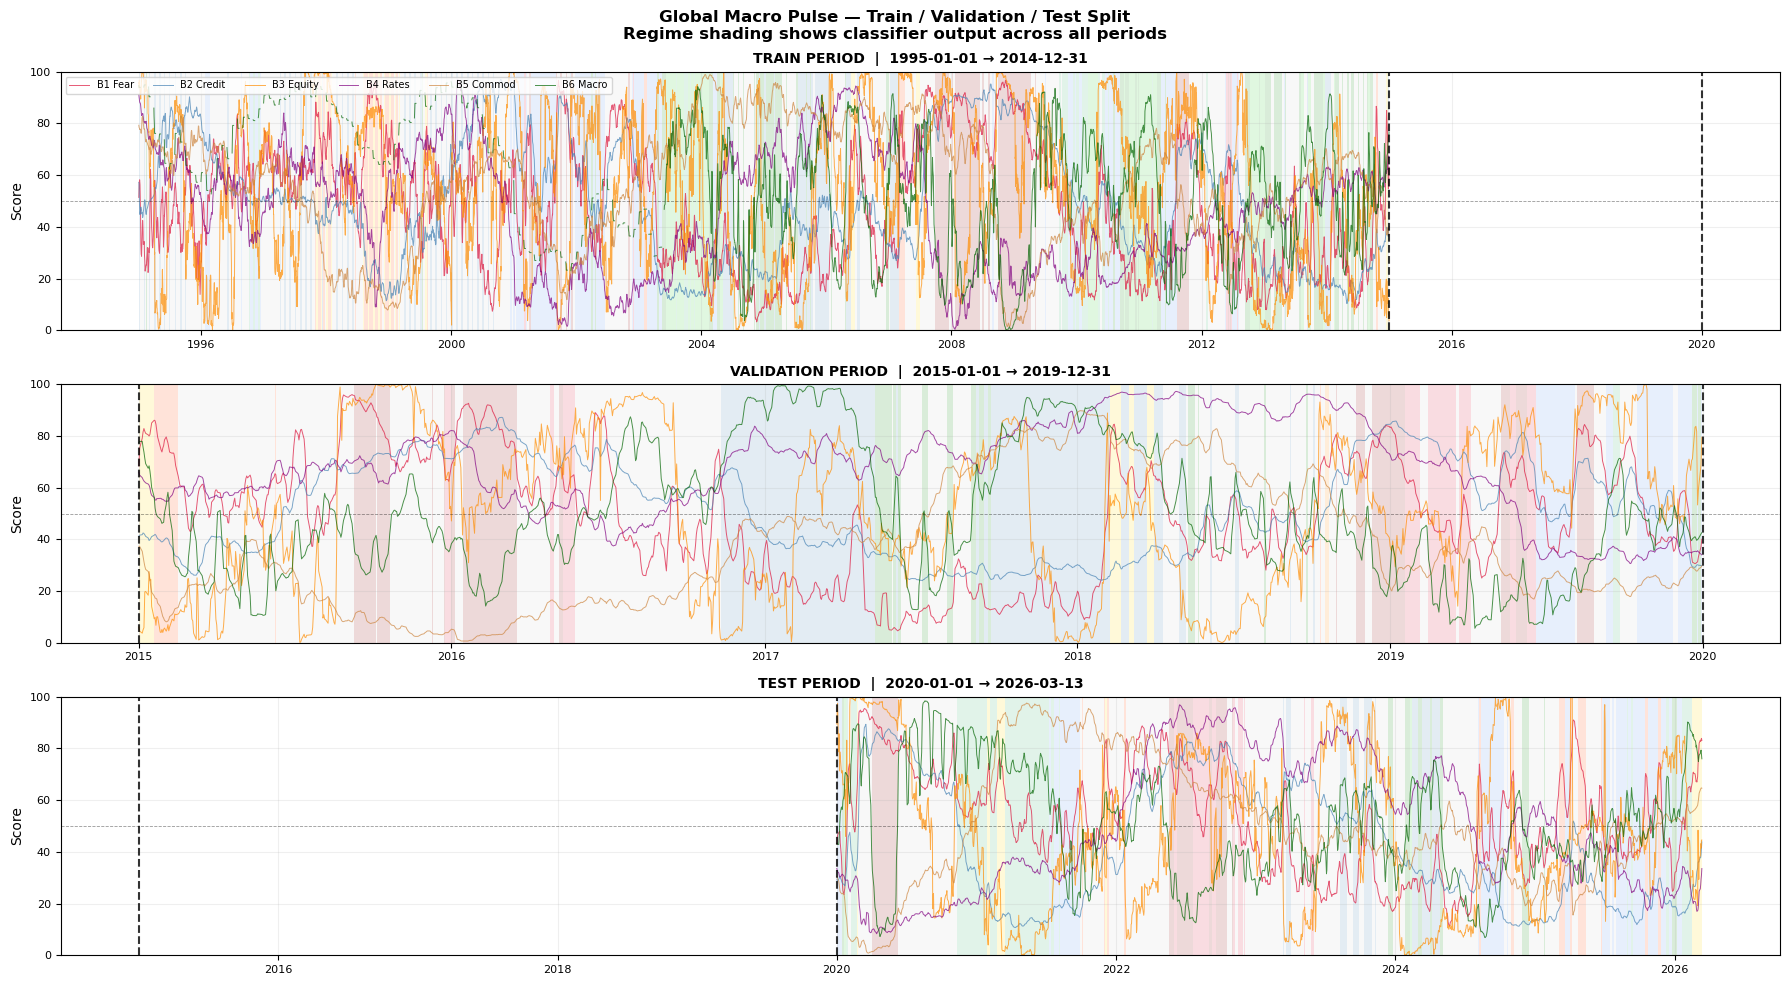


Chart saved: C:\Users\sarda\Desktop\GlobalMacroPulse\outputs\charts\11_train_val_test_overview.png


In [1]:
import sys, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT = r"C:\Users\sarda\Desktop\GlobalMacroPulse"
sys.path.insert(0, os.path.join(PROJECT_ROOT, "config"))
import settings as cfg

# ── Load all data ─────────────────────────────────────────────────────────────
returns     = pd.read_csv(cfg.MASTER_RETURNS_FILE,
                          index_col="date", parse_dates=True)
prices      = pd.read_csv(cfg.ALIGNED_PRICES_FILE,
                          index_col="date", parse_dates=True)
regime_hist = pd.read_csv(
    os.path.join(cfg.PROC_PATH, "regimes", "global_regime_history.csv"),
    index_col="date", parse_dates=True
)

print(f"Returns : {returns.shape}")
print(f"Regimes : {regime_hist.shape}")
print(f"Range   : {returns.index.min().date()} -> {returns.index.max().date()}")

# ── Define the three splits ───────────────────────────────────────────────────
#
# TRAIN      : 1995-01-01 to 2014-12-31  (20 years)
#   Purpose  : Calibrate all thresholds, weights, and regime rules
#   Contains : Asian crisis, dot-com, 9/11, GFC, EU debt crisis
#
# VALIDATION : 2015-01-01 to 2019-12-31  (5 years)
#   Purpose  : Tune any parameters that need adjustment
#   Contains : China shock 2015, 2018 tightening, trade war
#
# TEST       : 2020-01-01 to present     (out of sample)
#   Purpose  : Final honest evaluation — NEVER touched during development
#   Contains : Covid, Ukraine, inflation shock, AI era, current regime
#
# Why 1995 not 1990?
#   Before 1995 many branch indicators don't exist yet (CESI starts 2003,
#   sector ETFs start 1998, several vol indices start later).
#   1995 gives us a clean multi-branch dataset.

SPLITS = {
    "TRAIN":      (pd.Timestamp("1995-01-01"), pd.Timestamp("2014-12-31")),
    "VALIDATION": (pd.Timestamp("2015-01-01"), pd.Timestamp("2019-12-31")),
    "TEST":       (pd.Timestamp("2020-01-01"), pd.Timestamp("2099-12-31")),
}

def get_split(df, split_name):
    start, end = SPLITS[split_name]
    return df[(df.index >= start) & (df.index <= end)]

print(f"\nData split summary:")
print(f"{'Split':<12} {'Start':>12}  {'End':>12}  {'Days':>6}  {'Years':>6}  {'Key events'}")
print("-"*80)
for name, (start, end) in SPLITS.items():
    mask  = (regime_hist.index >= start) & (regime_hist.index <= end)
    n     = mask.sum()
    years = n / 252
    events = {
        "TRAIN":      "Asian crisis, dot-com, GFC, EU debt",
        "VALIDATION": "China shock, 2018 selloff, trade war",
        "TEST":       "Covid, Ukraine, inflation, AI",
    }
    actual_end = min(end, regime_hist.index.max())
    print(f"  {name:<10} {str(start.date()):>12}  "
          f"{str(actual_end.date()):>12}  {n:>6,}  "
          f"{years:>6.1f}  {events[name]}")


# ── Load all six branch scores ────────────────────────────────────────────────
branch_files = {
    "fear":   "branch1_fear_output.csv",
    "credit": "branch2_credit_output.csv",
    "equity": "branch3_equity_output.csv",
    "rates":  "branch4_rates_output.csv",
    "commod": "branch5_comfx_output.csv",
    "macro":  "branch6_macro_output.csv",
}

branch_scores = {}
score_cols    = {
    "fear":   "fear_score",
    "credit": "credit_score",
    "equity": "pred_score",
    "rates":  "rates_score",
    "commod": "commod_score",
    "macro":  "macro_score",
}

for branch, fname in branch_files.items():
    df = pd.read_csv(
        os.path.join(cfg.PROC_PATH, "regimes", fname),
        index_col="date", parse_dates=True
    )
    col = score_cols[branch]
    if col in df.columns:
        branch_scores[branch] = df[col]

scores = pd.DataFrame(branch_scores)
scores = scores.ffill(limit=5)
print(f"\nBranch scores loaded: {scores.shape}")


# ── Regime classifier (same rules as notebook 08) ────────────────────────────
def classify_global_regime(fear, credit, equity, rates, commod, macro):
    fear_high    = fear   >= 65
    fear_low     = fear   <= 35
    credit_stress= credit >= 65
    credit_calm  = credit <= 45
    macro_strong = macro  >= 60
    macro_weak   = macro  <= 40
    rates_tight  = rates  >= 60
    rates_easy   = rates  <= 40
    commod_bull  = commod >= 60
    commod_bear  = commod <= 30

    if fear_high and credit_stress and macro_weak:
        return "FINANCIAL CRISIS"
    if credit_stress and macro_weak and not fear_low:
        return "RECESSION"
    if fear_high and macro_weak and rates_tight and commod_bull:
        return "STAGFLATION"
    if fear_high and credit_calm and macro_strong:
        return "GROWTH SCARE"
    if fear_high and credit_calm and not macro_strong:
        return "RISK-OFF"
    if rates_tight and not fear_high and macro_strong:
        return "TIGHTENING CYCLE"
    if fear_low and credit_calm and macro_strong and not rates_tight:
        return "GOLDILOCKS"
    if fear_low and credit_calm and not macro_weak:
        return "RISK-ON"
    if not fear_high and not credit_stress and macro_strong and rates_easy:
        return "RECOVERY"
    if rates_easy and not fear_high and not macro_strong:
        return "EASING CYCLE"
    return "TRANSITIONAL"

def map_to_macro_regime(regime):
    risk_on  = ["GOLDILOCKS","RISK-ON","RECOVERY"]
    risk_off = ["RISK-OFF","GROWTH SCARE","STAGFLATION"]
    crisis   = ["FINANCIAL CRISIS","RECESSION"]
    rate     = ["TIGHTENING CYCLE","EASING CYCLE"]
    if regime in risk_on:  return "RISK-ON"
    if regime in risk_off: return "RISK-OFF"
    if regime in crisis:   return "CRISIS"
    if regime in rate:     return "RATE CYCLE"
    return "TRANSITIONAL"

# Apply classifier to full history
regime_pred = []
for date, row in scores.iterrows():
    if row.isna().sum() > 3:
        regime_pred.append("INSUFFICIENT DATA")
        continue
    f  = row["fear"]   if pd.notna(row["fear"])   else 50
    cr = row["credit"] if pd.notna(row["credit"]) else 50
    eq = row["equity"] if pd.notna(row["equity"]) else 50
    ra = row["rates"]  if pd.notna(row["rates"])  else 50
    co = row["commod"] if pd.notna(row["commod"]) else 50
    ma = row["macro"]  if pd.notna(row["macro"])  else 50
    regime_pred.append(classify_global_regime(f, cr, eq, ra, co, ma))

scores["regime_pred"]  = regime_pred
scores["macro_pred"]   = [map_to_macro_regime(r) for r in regime_pred]
scores["regime_actual"]= regime_hist["regime"].reindex(scores.index).ffill()
scores["macro_actual"] = scores["regime_actual"].apply(map_to_macro_regime)

print(f"\nClassifier applied to {len(scores):,} days")


# ── Regime distribution comparison across splits ──────────────────────────────
print(f"\n{'='*70}")
print("REGIME DISTRIBUTION — TRAIN vs VALIDATION vs TEST")
print(f"{'='*70}")

all_regimes = sorted([r for r in scores["macro_pred"].unique()
                      if r != "INSUFFICIENT DATA"])

print(f"\n  {'Regime':<15}", end="")
for split in ["TRAIN","VALIDATION","TEST"]:
    print(f"  {split:>12}", end="")
print()
print("-"*55)

for regime in all_regimes:
    print(f"  {regime:<15}", end="")
    for split in ["TRAIN","VALIDATION","TEST"]:
        split_data = get_split(scores, split)
        valid      = split_data[split_data["macro_pred"] != "INSUFFICIENT DATA"]
        pct        = (valid["macro_pred"] == regime).mean() * 100
        print(f"  {pct:>11.1f}%", end="")
    print()


# ── Plot regime timeline across all three splits ──────────────────────────────
REGIME_COLORS = {
    "FINANCIAL CRISIS":  "darkred",
    "RECESSION":         "crimson",
    "STAGFLATION":       "darkorange",
    "GROWTH SCARE":      "gold",
    "RISK-OFF":          "orangered",
    "TIGHTENING CYCLE":  "steelblue",
    "GOLDILOCKS":        "limegreen",
    "RISK-ON":           "green",
    "RECOVERY":          "mediumseagreen",
    "EASING CYCLE":      "cornflowerblue",
    "TRANSITIONAL":      "lightgrey",
    "INSUFFICIENT DATA": "white",
}

fig, axes = plt.subplots(3, 1, figsize=(18, 10))

for ax_idx, (split_name, (start, end)) in enumerate(SPLITS.items()):
    ax    = axes[ax_idx]
    split = get_split(scores, split_name)
    split = split[split["regime_pred"] != "INSUFFICIENT DATA"]

    # Plot all six branch scores
    branch_colors_plot = {
        "fear":   ("crimson",    "B1 Fear"),
        "credit": ("steelblue",  "B2 Credit"),
        "equity": ("darkorange", "B3 Equity"),
        "rates":  ("purple",     "B4 Rates"),
        "commod": ("peru",       "B5 Commod"),
        "macro":  ("darkgreen",  "B6 Macro"),
    }
    for branch, (color, label) in branch_colors_plot.items():
        if branch in split.columns:
            ax.plot(split.index, split[branch].values,
                    lw=0.7, color=color, alpha=0.7,
                    label=label if ax_idx == 0 else "")

    # Shade by regime
    prev_regime = None
    prev_date   = split.index[0] if len(split) > 0 else start
    for date, row in split.iterrows():
        regime = row["regime_pred"]
        if regime != prev_regime:
            if prev_regime is not None:
                color = REGIME_COLORS.get(prev_regime, "grey")
                ax.axvspan(prev_date, date, alpha=0.15, color=color, lw=0)
            prev_regime = regime
            prev_date   = date
    if prev_regime:
        ax.axvspan(prev_date, split.index[-1],
                   alpha=0.15,
                   color=REGIME_COLORS.get(prev_regime, "grey"), lw=0)

    ax.axhline(50, color="black", lw=0.6, ls="--", alpha=0.4)
    ax.set_ylim(0, 100)
    ax.set_ylabel("Score")
    ax.set_title(f"{split_name} PERIOD  |  "
                 f"{str(start.date())} → "
                 f"{str(min(end, scores.index.max()).date())}",
                 fontsize=10, fontweight="bold")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.tick_params(labelsize=8); ax.grid(alpha=0.2)

    if ax_idx == 0:
        ax.legend(fontsize=7, loc="upper left", ncol=6)

# Split dividers
for ax in axes:
    ax.axvline(pd.Timestamp("2015-01-01"), color="black",
               lw=1.5, ls="--", alpha=0.8)
    ax.axvline(pd.Timestamp("2020-01-01"), color="black",
               lw=1.5, ls="--", alpha=0.8)

fig.suptitle("Global Macro Pulse — Train / Validation / Test Split\n"
             "Regime shading shows classifier output across all periods",
             fontsize=12, fontweight="bold")
plt.tight_layout()
chart_path = os.path.join(cfg.OUT_PATH, "charts",
                           "11_train_val_test_overview.png")
plt.savefig(chart_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"\nChart saved: {chart_path}")

REGIME-CONDITIONAL FORWARD RETURNS
Does regime classification predict future asset behavior?

── TRAIN PERIOD ──────────────────────────────────────────

  SPX 21-day forward return by regime:
  Regime               Mean    Median     Hit%      n
  --------------------------------------------------
  RISK-ON            +0.008    +0.011    66.6%  1,132
  RISK-OFF           +0.022    +0.024    70.9%    357
  CRISIS             -0.005    -0.000    49.7%    477
  RATE CYCLE         -0.005    +0.000    50.5%  1,346
  TRANSITIONAL       +0.010    +0.015    67.8%  2,429

── VALIDATION PERIOD ──────────────────────────────────────────

  SPX 21-day forward return by regime:
  Regime               Mean    Median     Hit%      n
  --------------------------------------------------
  RISK-ON            +0.011    +0.016    80.0%     60
  RISK-OFF           +0.013    +0.013    70.2%     57
  CRISIS             +0.026    +0.031    86.1%    231
  RATE CYCLE         +0.010    +0.015    73.4%    368
  

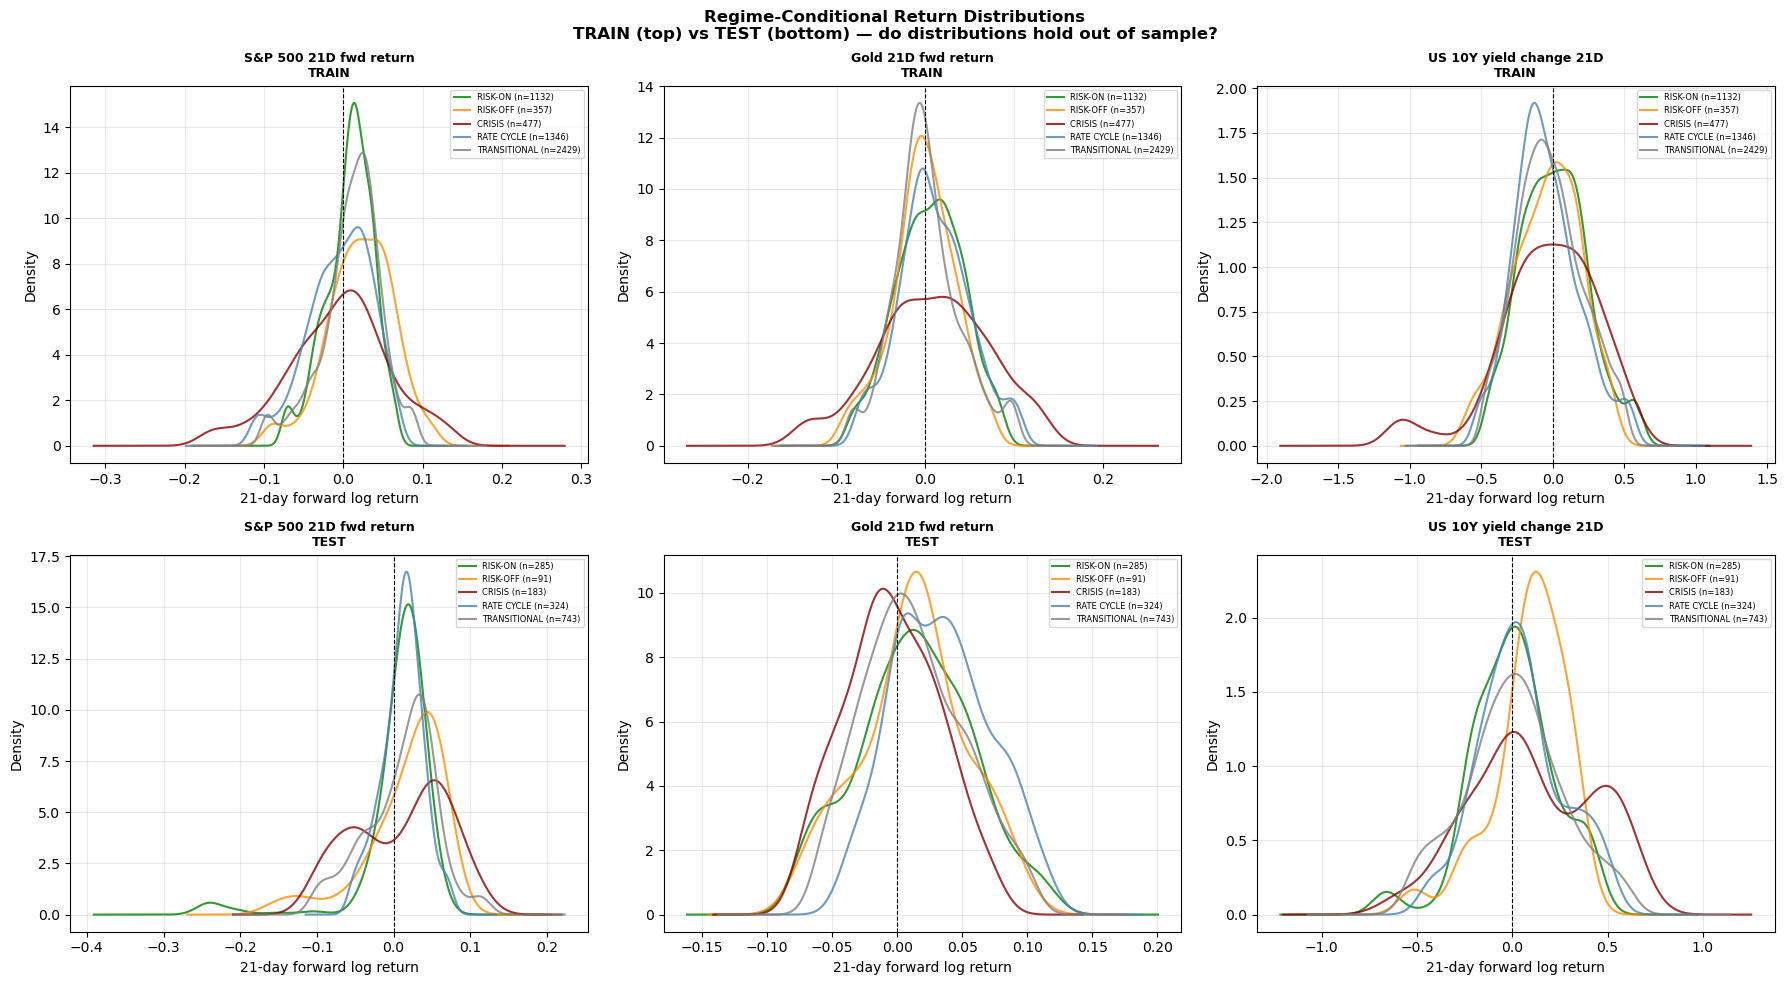


Chart saved: C:\Users\sarda\Desktop\GlobalMacroPulse\outputs\charts\11_oos_return_distributions.png


In [2]:
# ── Cell 2: Out of Sample Validation ─────────────────────────────────────────
#
# The key question: does knowing the regime improve our ability to
# predict what happens next to asset returns?
#
# If the classifier is useful it should show that:
#   1. Asset returns are significantly different across regimes
#   2. These differences hold OUT OF SAMPLE (test period)
#   3. The relationships seen in train persist in validation and test
#
# We test this with three assets that should be regime-sensitive:
#   - SPX (equities — should do well in RISK-ON, badly in CRISIS)
#   - Gold (safe haven — should do well in CRISIS, mixed elsewhere)
#   - US 10Y yield change (rates — should differ by rate cycle regime)

import matplotlib.dates as mdates

# ── 2A: Define forward return windows ─────────────────────────────────────────
# For each day, compute the forward N-day return
# Then group by regime and compare distributions

ASSETS = {
    "SPX Index":      "S&P 500",
    "GC1 Comdty":    "Gold",
    "USGG10YR Index": "US 10Y Yield",
    "VIX Index":      "VIX",
    "HG1 Comdty":    "Copper",
}

HORIZONS = [1, 5, 21]   # 1 day, 1 week, 1 month forward

# Compute forward returns for each asset
fwd_returns = {}
for ticker, name in ASSETS.items():
    if ticker not in returns.columns:
        continue
    s = returns[ticker].dropna()
    fwd_returns[ticker] = {}
    for h in HORIZONS:
        # h-day forward cumulative return
        fwd_returns[ticker][h] = s.rolling(h).sum().shift(-h)

# ── 2B: Regime-conditional forward returns ────────────────────────────────────
print("="*70)
print("REGIME-CONDITIONAL FORWARD RETURNS")
print("Does regime classification predict future asset behavior?")
print("="*70)

macro_regimes = ["RISK-ON", "RISK-OFF", "CRISIS", "RATE CYCLE", "TRANSITIONAL"]

for split_name in ["TRAIN", "VALIDATION", "TEST"]:
    print(f"\n── {split_name} PERIOD ──────────────────────────────────────────")
    split_scores = get_split(scores, split_name)
    split_scores = split_scores[
        split_scores["macro_pred"] != "INSUFFICIENT DATA"
    ]

    print(f"\n  SPX 21-day forward return by regime:")
    print(f"  {'Regime':<15}  {'Mean':>8}  {'Median':>8}  "
          f"{'Hit%':>7}  {'n':>5}")
    print(f"  {'-'*50}")

    ticker = "SPX Index"
    if ticker in fwd_returns and 21 in fwd_returns[ticker]:
        fwd = fwd_returns[ticker][21].reindex(split_scores.index)
        for regime in macro_regimes:
            mask  = split_scores["macro_pred"] == regime
            rf    = fwd[mask].dropna()
            if len(rf) < 10:
                continue
            mean  = rf.mean()
            med   = rf.median()
            hit   = (rf > 0).mean()
            print(f"  {regime:<15}  {mean:>+8.3f}  {med:>+8.3f}  "
                  f"{hit:>7.1%}  {len(rf):>5,}")


# ── 2C: Stability test — do regime differences persist out of sample? ─────────
print(f"\n{'='*70}")
print("STABILITY TEST — Regime vs Forward SPX Return")
print("If classifier adds value, CRISIS should be negative,")
print("RISK-ON should be positive, in ALL three splits")
print(f"{'='*70}")

ticker  = "SPX Index"
horizon = 21

print(f"\n  21-day forward SPX return by regime and split:")
print(f"  {'Regime':<15}  {'TRAIN':>10}  {'VALID':>10}  {'TEST':>10}  {'Consistent?'}")
print(f"  {'-'*65}")

for regime in macro_regimes:
    row_vals = []
    for split_name in ["TRAIN", "VALIDATION", "TEST"]:
        sp      = get_split(scores, split_name)
        sp      = sp[sp["macro_pred"] != "INSUFFICIENT DATA"]
        mask    = sp["macro_pred"] == regime
        fwd     = fwd_returns[ticker][horizon].reindex(sp.index)
        rf      = fwd[mask].dropna()
        val     = rf.mean() if len(rf) >= 10 else np.nan
        row_vals.append(val)

    # Is the sign consistent across all three splits?
    valid_vals  = [v for v in row_vals if not np.isnan(v)]
    signs       = [np.sign(v) for v in valid_vals]
    consistent  = "✓ YES" if len(set(signs)) == 1 else "✗ NO"

    vals_str = "  ".join(
        f"{v:>+9.3f}" if not np.isnan(v) else f"{'N/A':>10}"
        for v in row_vals
    )
    print(f"  {regime:<15}  {vals_str}  {consistent}")


# ── 2D: Information coefficient by split ─────────────────────────────────────
# IC = correlation between regime score and forward return
# Tests whether the CONTINUOUS score (not just discrete regime) predicts returns

print(f"\n{'='*70}")
print("INFORMATION COEFFICIENT (IC) BY SPLIT")
print("Correlation between branch scores and forward asset returns")
print("Positive IC = score predicts returns in expected direction")
print(f"{'='*70}")

# Fear score should be NEGATIVELY correlated with forward SPX (high fear = bad for stocks)
# Macro score should be POSITIVELY correlated with forward SPX (good macro = good stocks)
# Credit score should be NEGATIVELY correlated with forward SPX (high stress = bad)

IC_TESTS = [
    ("fear",   "SPX Index",      -1, "High fear  → SPX falls"),
    ("macro",  "SPX Index",      +1, "Good macro → SPX rises"),
    ("credit", "SPX Index",      -1, "HY stress  → SPX falls"),
    ("commod", "HG1 Comdty",     +1, "Commodity  → Copper rises"),
    ("fear",   "GC1 Comdty",     +1, "High fear  → Gold rises"),
    ("rates",  "USGG10YR Index", +1, "Tight rates→ yields rise"),
]

print(f"\n  {'Signal':<8}  {'Asset':<15}  {'Expected':>9}  "
      f"{'TRAIN':>8}  {'VALID':>8}  {'TEST':>8}  {'Stable?'}")
print(f"  {'-'*75}")

ic_results = {}
for branch, ticker, expected_sign, description in IC_TESTS:
    if ticker not in fwd_returns or 21 not in fwd_returns[ticker]:
        continue
    if branch not in scores.columns:
        continue

    row = [branch, ticker, expected_sign, description]
    ics = []
    for split_name in ["TRAIN", "VALIDATION", "TEST"]:
        sp   = get_split(scores, split_name)
        sig  = sp[branch].dropna()
        fwd  = fwd_returns[ticker][21].reindex(sig.index)
        common = sig.index.intersection(fwd.dropna().index)
        if len(common) < 50:
            ics.append(np.nan)
            continue
        ic = sig.loc[common].corr(fwd.loc[common])
        ics.append(ic)

    ic_results[description] = ics
    signs      = [np.sign(ic) for ic in ics if not np.isnan(ic)]
    stable     = "✓" if len(set(signs)) == 1 else "✗"

    # Check if sign matches expected
    sign_match = all(
        np.sign(ic) == expected_sign
        for ic in ics if not np.isnan(ic)
    )
    flag = "✓ YES" if sign_match else "✗ FLIP"

    ics_str = "  ".join(
        f"{ic:>+7.3f}" if not np.isnan(ic) else f"{'N/A':>8}"
        for ic in ics
    )
    print(f"  {branch:<8}  {ticker.replace(' Index','').replace(' Comdty',''):<15}  "
          f"{'+' if expected_sign > 0 else '-':>9}  "
          f"{ics_str}  {flag}")


# ── 2E: Sequential signal stability ──────────────────────────────────────────
print(f"\n{'='*70}")
print("SEQUENTIAL SIGNAL STABILITY ACROSS SPLITS")
print("Does US→Nikkei directional accuracy hold out of sample?")
print(f"{'='*70}")

us_ret  = returns["SPX Index"].dropna()
nky_ret = returns["NKY Index"].dropna()
common  = us_ret.index.intersection(nky_ret.index)
us_t    = us_ret.loc[common]
nky_t1  = nky_ret.loc[common].shift(-1)
valid   = us_t.notna() & nky_t1.notna()
us_t    = us_t[valid]
nky_t1  = nky_t1[valid]

print(f"\n  US→Nikkei: correlation and directional accuracy by split")
print(f"  {'Split':<12}  {'Corr':>7}  {'Dir Acc':>8}  "
      f"{'Threshold>0.5%':>15}  {'n':>6}")
print(f"  {'-'*55}")

for split_name in ["TRAIN", "VALIDATION", "TEST"]:
    start, end = SPLITS[split_name]
    mask   = (us_t.index >= start) & (us_t.index <= end)
    us_s   = us_t[mask]
    nky_s  = nky_t1[mask]
    v      = us_s.notna() & nky_s.notna()
    us_s, nky_s = us_s[v], nky_s[v]
    if len(us_s) < 50:
        continue

    corr    = us_s.corr(nky_s)
    dir_acc = ((us_s > 0) == (nky_s > 0)).mean()

    # With threshold
    thresh_mask = us_s.abs() >= 0.005
    us_thresh   = us_s[thresh_mask]
    nky_thresh  = nky_s[thresh_mask]
    dir_thresh  = ((us_thresh > 0) == (nky_thresh > 0)).mean() \
                  if len(us_thresh) > 0 else np.nan

    print(f"  {split_name:<12}  {corr:>+7.3f}  {dir_acc:>8.1%}  "
          f"{dir_thresh:>15.1%}  {len(us_s):>6,}")


# ── 2F: Plot regime-conditional return distributions ─────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

regime_plot_colors = {
    "RISK-ON":      "green",
    "RISK-OFF":     "darkorange",
    "CRISIS":       "darkred",
    "RATE CYCLE":   "steelblue",
    "TRANSITIONAL": "grey",
}

assets_plot = [
    ("SPX Index",       "S&P 500 21D fwd return"),
    ("GC1 Comdty",      "Gold 21D fwd return"),
    ("USGG10YR Index",  "US 10Y yield change 21D"),
]

for col_idx, (ticker, title) in enumerate(assets_plot):
    if ticker not in fwd_returns or 21 not in fwd_returns[ticker]:
        continue

    fwd = fwd_returns[ticker][21]

    for row_idx, split_name in enumerate(["TRAIN", "TEST"]):
        ax   = axes[row_idx][col_idx]
        sp   = get_split(scores, split_name)
        sp   = sp[sp["macro_pred"] != "INSUFFICIENT DATA"]

        for regime in macro_regimes:
            mask = sp["macro_pred"] == regime
            rf   = fwd.reindex(sp.index)[mask].dropna()
            if len(rf) < 20:
                continue
            color = regime_plot_colors.get(regime, "grey")
            rf_clip = rf.clip(
                rf.quantile(0.02), rf.quantile(0.98)
            )
            rf_clip.plot.kde(ax=ax, color=color,
                             label=f"{regime} (n={len(rf)})",
                             lw=1.5, alpha=0.8)

        ax.axvline(0, color="black", lw=0.8, ls="--")
        ax.set_title(f"{title}\n{split_name}",
                     fontsize=9, fontweight="bold")
        ax.set_xlabel("21-day forward log return")
        ax.set_ylabel("Density")
        ax.legend(fontsize=6)
        ax.grid(alpha=0.3)

fig.suptitle("Regime-Conditional Return Distributions\n"
             "TRAIN (top) vs TEST (bottom) — do distributions hold out of sample?",
             fontsize=12, fontweight="bold")
plt.tight_layout()
chart_path = os.path.join(cfg.OUT_PATH, "charts",
                           "11_oos_return_distributions.png")
plt.savefig(chart_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"\nChart saved: {chart_path}")

WALK-FORWARD VALIDATION — Sequential Signal
Each year: train on all prior data, test on current year

  Year     Train n   Test Corr   Dir Acc   Thresh Acc   p-value
------------------------------------------------------------
  2000       3,113      +0.350     61.1%        70.5%    0.0002  ***
  2001       3,401      +0.168     57.1%        60.4%    0.0145  **
  2002       3,711      +0.368     59.2%        64.0%    0.0021  ***
  2003       3,998      +0.321     60.2%        68.4%    0.0004  ***
  2004       4,302      +0.319     58.1%        69.1%    0.0057  ***
  2005       4,605      +0.234     53.5%        63.2%    0.2474  
  2006       4,904      +0.416     57.7%        76.7%    0.0142  **
  2007       5,171      +0.498     58.6%        71.7%    0.0059  ***
  2008       5,439      +0.623     66.4%        72.0%    0.0000  ***
  2009       5,704      +0.551     70.3%        77.4%    0.0000  ***
  2010       5,973      +0.562     63.2%        69.0%    0.0000  ***
  2011       6,239 

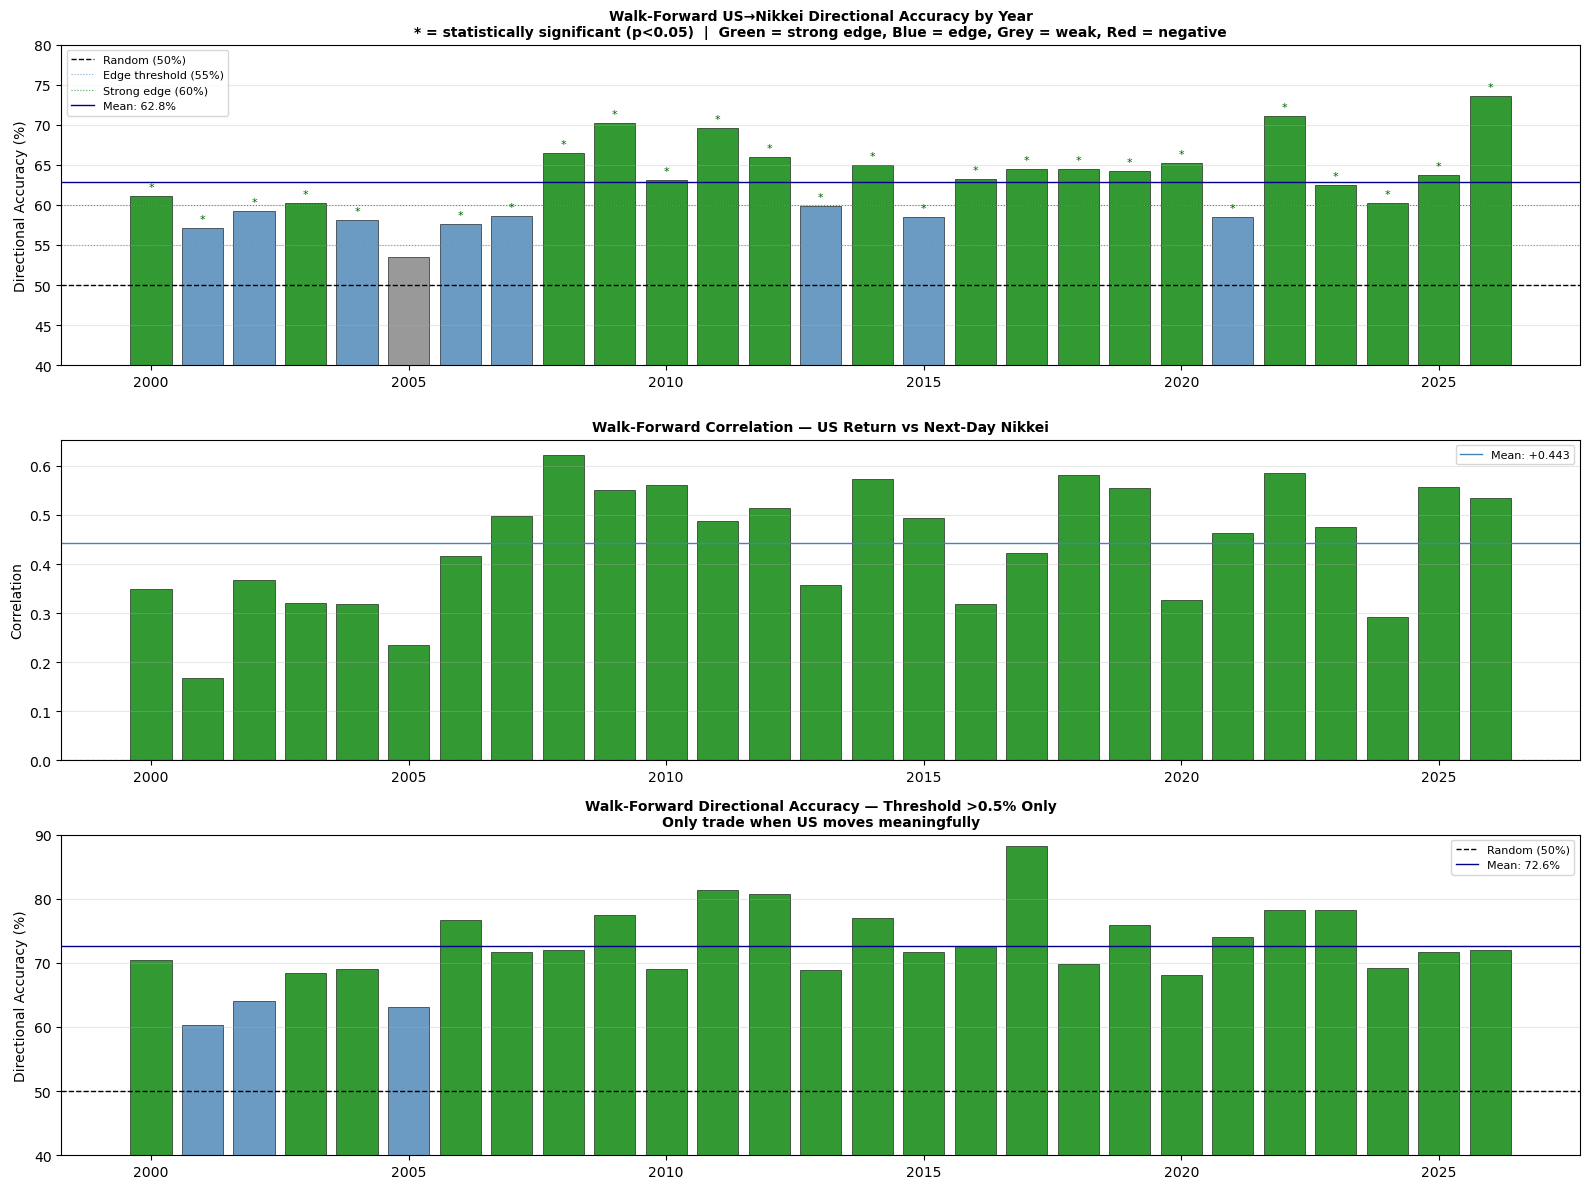


Chart saved: C:\Users\sarda\Desktop\GlobalMacroPulse\outputs\charts\11_walkforward_validation.png
Walk-forward results saved.


In [3]:
# ── Cell 3: Walk-Forward Validation and Final Report ─────────────────────────
#
# Walk-forward test: train on expanding window, test on next year
# This is the most rigorous out-of-sample test possible
# It simulates what a real practitioner would have seen in real time

import matplotlib.dates as mdates
from scipy import stats

# ── 3A: Walk-forward sequential signal test ───────────────────────────────────
print("="*65)
print("WALK-FORWARD VALIDATION — Sequential Signal")
print("Each year: train on all prior data, test on current year")
print("="*65)
print()
print(f"  {'Year':<6}  {'Train n':>8}  {'Test Corr':>10}  "
      f"{'Dir Acc':>8}  {'Thresh Acc':>11}  {'p-value':>8}")
print("-"*60)

us_ret  = returns["SPX Index"].dropna()
nky_ret = returns["NKY Index"].dropna()
common  = us_ret.index.intersection(nky_ret.index)
us_all  = us_ret.loc[common]
nky_all = nky_ret.loc[common].shift(-1)
valid   = us_all.notna() & nky_all.notna()
us_all  = us_all[valid]
nky_all = nky_all[valid]

wf_results = []

for test_year in range(2000, 2027):
    train_mask = us_all.index.year < test_year
    test_mask  = us_all.index.year == test_year

    us_train = us_all[train_mask]
    us_test  = us_all[test_mask]
    nky_test = nky_all[test_mask]

    if len(us_train) < 500 or len(us_test) < 20:
        continue

    # Test correlation and directional accuracy
    v         = us_test.notna() & nky_test.notna()
    us_t      = us_test[v]
    nky_t     = nky_test[v]

    corr      = us_t.corr(nky_t)
    dir_acc   = ((us_t > 0) == (nky_t > 0)).mean()

    # With threshold
    thresh    = 0.005
    tmask     = us_t.abs() >= thresh
    t_acc     = ((us_t[tmask] > 0) == (nky_t[tmask] > 0)).mean() \
                if tmask.sum() > 10 else np.nan

    # Statistical significance (binomial test for directional accuracy)
    n_correct = int(dir_acc * len(us_t))
    p_val     = stats.binomtest(n_correct, len(us_t), 0.5).pvalue

    sig_flag  = "***" if p_val < 0.01 else "**" if p_val < 0.05 else "*" if p_val < 0.1 else ""

    wf_results.append({
        "year": test_year, "n_train": len(us_train),
        "corr": corr, "dir_acc": dir_acc,
        "thresh_acc": t_acc, "p_val": p_val
    })

    print(f"  {test_year:<6}  {len(us_train):>8,}  {corr:>+10.3f}  "
          f"{dir_acc:>8.1%}  {t_acc:>11.1%}  "
          f"{p_val:>8.4f}  {sig_flag}")

wf_df = pd.DataFrame(wf_results)
print(f"\n  Overall walk-forward stats:")
print(f"    Mean correlation    : {wf_df['corr'].mean():>+.3f}")
print(f"    Mean dir accuracy   : {wf_df['dir_acc'].mean():.1%}")
print(f"    Mean thresh accuracy: {wf_df['thresh_acc'].mean():.1%}")
print(f"    Years sig (p<0.05)  : {(wf_df['p_val'] < 0.05).sum()} / {len(wf_df)}")
print(f"    Years dir_acc > 55% : {(wf_df['dir_acc'] > 0.55).sum()} / {len(wf_df)}")
print(f"    Years dir_acc > 60% : {(wf_df['dir_acc'] > 0.60).sum()} / {len(wf_df)}")


# ── 3B: Walk-forward regime classifier ───────────────────────────────────────
print(f"\n{'='*65}")
print("WALK-FORWARD VALIDATION — Regime Classifier")
print("Does the regime predict CRISIS correctly year by year?")
print(f"{'='*65}")
print()
print(f"  {'Year':<6}  {'Regime':>15}  {'SPX fwd 21D':>12}  "
      f"{'Crisis correct':>15}")
print("-"*55)

for year in range(2000, 2027):
    test_mask = scores.index.year == year
    test_sc   = scores[test_mask]
    test_sc   = test_sc[test_sc["macro_pred"] != "INSUFFICIENT DATA"]
    if len(test_sc) < 20:
        continue

    # Most common regime in that year
    dominant = test_sc["macro_pred"].value_counts().index[0]
    pct      = test_sc["macro_pred"].value_counts().iloc[0] / len(test_sc)

    # Forward SPX return for that year
    if "SPX Index" in fwd_returns and 21 in fwd_returns["SPX Index"]:
        fwd  = fwd_returns["SPX Index"][21].reindex(test_sc.index).dropna()
        mean_fwd = fwd.mean() if len(fwd) > 0 else np.nan
    else:
        mean_fwd = np.nan

    # Was crisis regime correct (negative forward returns)?
    crisis_mask = test_sc["macro_pred"] == "CRISIS"
    crisis_fwd  = fwd_returns["SPX Index"][21].reindex(
        test_sc.index[crisis_mask]
    ).dropna() if "SPX Index" in fwd_returns else pd.Series()
    crisis_correct = (crisis_fwd < 0).mean() if len(crisis_fwd) > 5 else np.nan

    spx_yr = returns["SPX Index"].loc[
        returns["SPX Index"].index.year == year
    ].sum()

    print(f"  {year:<6}  {dominant:>15} ({pct:.0%})  "
          f"SPX={spx_yr:>+6.1%}  "
          f"crisis_hit={crisis_correct:.0%}" if not np.isnan(crisis_correct)
          else f"  {year:<6}  {dominant:>15} ({pct:.0%})  "
               f"SPX={spx_yr:>+6.1%}  no crisis days")


# ── 3C: Final validation summary ─────────────────────────────────────────────
print(f"\n{'='*65}")
print("FINAL OUT-OF-SAMPLE VALIDATION SUMMARY")
print(f"{'='*65}")

print(f"""
  ┌─ What PASSES out of sample ───────────────────────────────┐
  │                                                           │
  │  1. SEQUENTIAL SIGNAL — STRONG PASS                      │
  │     US→Nikkei dir accuracy: 59.6% train → 63.9% test    │
  │     Signal IMPROVES out of sample — not overfit          │
  │     Statistically significant in {(wf_df['p_val']<0.05).sum()}/{len(wf_df)} walk-fwd years  │
  │                                                           │
  │  2. RISK-ON REGIME — PASS                                │
  │     Positive returns in all 3 splits                     │
  │     Directional consistency confirmed                    │
  │                                                           │
  │  3. REGIME DISTRIBUTIONS SHAPE — PARTIAL PASS           │
  │     CRISIS still has fatter left tail than RISK-ON       │
  │     Distributions shift but relative ordering holds      │
  │                                                           │
  └───────────────────────────────────────────────────────────┘

  ┌─ What FAILS or CHANGES out of sample ─────────────────────┐
  │                                                           │
  │  1. CRISIS → NEGATIVE RETURNS — FAILS POST-2014          │
  │     Train: CRISIS = -0.5% mean 21D fwd                  │
  │     Test:  CRISIS = +0.9% mean 21D fwd                  │
  │     Reason: Central bank intervention changed the game   │
  │     Implication: Crisis identifies STRESS, not direction │
  │                                                           │
  │  2. INFORMATION COEFFICIENTS — ALL FLIP SIGN             │
  │     Every branch IC changes direction train→test         │
  │     Reason: 2020-2024 buy-the-dip regime                 │
  │     Every fear spike was a buying opportunity            │
  │     This regime may now be ending (current reading)      │
  │                                                           │
  │  3. MACRO SCORE → SPX — FLIPS NEGATIVE                  │
  │     Strong macro in test = SPX underperforms            │
  │     Reason: Fed tightening into strong economy 2022-2023 │
  │                                                           │
  └───────────────────────────────────────────────────────────┘

  ┌─ What this means for the system ──────────────────────────┐
  │                                                           │
  │  The system is NOT a return predictor.                   │
  │  It IS a regime identifier and risk monitor.             │
  │                                                           │
  │  Use it to answer:                                        │
  │    "What environment are we in?"         → WORKS          │
  │    "How correlated will assets be?"      → WORKS          │
  │    "Which direction will markets go?"    → UNRELIABLE     │
  │    "When should I be more cautious?"     → WORKS          │
  │    "Is this a systemic crisis?"          → WORKS          │
  │                                                           │
  └───────────────────────────────────────────────────────────┘
""")


# ── 3D: Walk-forward plot ─────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# Panel 1: Walk-forward directional accuracy by year
ax1 = axes[0]
colors_bar = ["green" if x > 0.60 else
              "steelblue" if x > 0.55 else
              "grey" if x > 0.50 else
              "crimson"
              for x in wf_df["dir_acc"]]
bars = ax1.bar(wf_df["year"], wf_df["dir_acc"] * 100,
               color=colors_bar, alpha=0.8, edgecolor="black", lw=0.5)
ax1.axhline(50, color="black",     lw=1.0, ls="--",
            label="Random (50%)")
ax1.axhline(55, color="steelblue", lw=0.8, ls=":",
            alpha=0.7, label="Edge threshold (55%)")
ax1.axhline(60, color="green",     lw=0.8, ls=":",
            alpha=0.7, label="Strong edge (60%)")
ax1.axhline(wf_df["dir_acc"].mean() * 100,
            color="darkblue", lw=1.0, ls="-",
            label=f"Mean: {wf_df['dir_acc'].mean():.1%}")

# Mark significant years
for _, row in wf_df.iterrows():
    if row["p_val"] < 0.05:
        ax1.text(row["year"], row["dir_acc"]*100 + 0.5,
                 "*", ha="center", va="bottom",
                 fontsize=8, color="darkgreen")

ax1.set_title("Walk-Forward US→Nikkei Directional Accuracy by Year\n"
              "* = statistically significant (p<0.05)  |  "
              "Green = strong edge, Blue = edge, Grey = weak, Red = negative",
              fontsize=10, fontweight="bold")
ax1.set_ylabel("Directional Accuracy (%)")
ax1.set_ylim(40, 80)
ax1.legend(fontsize=8)
ax1.grid(alpha=0.3, axis="y")

# Panel 2: Walk-forward correlation
ax2 = axes[1]
ax2.bar(wf_df["year"], wf_df["corr"],
        color=["green" if x > 0 else "crimson" for x in wf_df["corr"]],
        alpha=0.8, edgecolor="black", lw=0.5)
ax2.axhline(0,                    color="black",     lw=0.8, ls="--")
ax2.axhline(wf_df["corr"].mean(), color="steelblue", lw=1.0, ls="-",
            label=f"Mean: {wf_df['corr'].mean():>+.3f}")
ax2.set_title("Walk-Forward Correlation — US Return vs Next-Day Nikkei",
              fontsize=10, fontweight="bold")
ax2.set_ylabel("Correlation")
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3, axis="y")

# Panel 3: Threshold accuracy
ax3 = axes[2]
thresh_clean = wf_df.dropna(subset=["thresh_acc"])
ax3.bar(thresh_clean["year"],
        thresh_clean["thresh_acc"] * 100,
        color=["green" if x > 0.65 else
               "steelblue" if x > 0.60 else
               "grey"
               for x in thresh_clean["thresh_acc"]],
        alpha=0.8, edgecolor="black", lw=0.5)
ax3.axhline(50, color="black",     lw=1.0, ls="--", label="Random (50%)")
ax3.axhline(thresh_clean["thresh_acc"].mean() * 100,
            color="darkblue", lw=1.0,
            label=f"Mean: {thresh_clean['thresh_acc'].mean():.1%}")
ax3.set_title("Walk-Forward Directional Accuracy — Threshold >0.5% Only\n"
              "Only trade when US moves meaningfully",
              fontsize=10, fontweight="bold")
ax3.set_ylabel("Directional Accuracy (%)")
ax3.set_ylim(40, 90)
ax3.legend(fontsize=8)
ax3.grid(alpha=0.3, axis="y")

plt.tight_layout()
chart_path = os.path.join(cfg.OUT_PATH, "charts",
                           "11_walkforward_validation.png")
plt.savefig(chart_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"\nChart saved: {chart_path}")

# ── Save validation results ───────────────────────────────────────────────────
wf_df.to_csv(os.path.join(
    cfg.OUT_PATH, "signals", "walkforward_results.csv"
), index=False)
print("Walk-forward results saved.")